## Learn to classify

Sample using scikit-learn "Machine Learning in Python" to create efficient MAV code.

In this example a simple color classifier is learned from sample data.

Add some images and labels to the data folder. 
 - Image file names should end with c.jpg 
 - Masks/labels should be black and white images with a filename ending with m.jpg

In [14]:
# Cell 2: Load and Pair the Images
import cv2
import numpy as np
import glob

# Search both the current folder and a 'data' folder just in case
all_images = glob.glob('*.jpg') + glob.glob('./data/*.jpg')

# Find raw images (ignoring masks)
raw_images = [f for f in all_images if not f.endswith('_m.jpg') and not f.endswith('m.jpg')]

images = []
labels = []

for img_path in raw_images:
    # Check for the matching mask file
    mask_path1 = img_path.replace('.jpg', '_m.jpg')
    mask_path2 = img_path.replace('c.jpg', 'm.jpg')
    
    if mask_path1 in all_images:
        images.append(img_path)
        labels.append(mask_path1)
    elif mask_path2 in all_images:
        images.append(img_path)
        labels.append(mask_path2)

print(f"✅ Successfully paired {len(images)} raw images with their masks!")

✅ Successfully paired 21 raw images with their masks!


From all the images and all the masks, create one large vector containing all training samples. 
 - The input vector has three columns for Y U V
 - The output has the label, ground or non-ground
 
 _Tip: modify the code to add several adjacent pixels as inputs_

In [15]:
# Cell 3: Extract U and V Pixels
X_vec = []
y_vec = []

if len(images) == 0:
    print("❌ ERROR: 0 images were found! Please put your images in the same folder as this notebook.")
else:
    for f, l in zip(images, labels):
        print(f"Processing {f}...")
        img = cv2.imread(f)
        mask = cv2.imread(l, cv2.IMREAD_GRAYSCALE)
        
        h, w, d = img.shape
        yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
        
        # Subsample: look at every 10th pixel to speed up training
        for y in range(0, h, 10):
            for x in range(0, w, 10):
                p = yuv[y, x]
                m = mask[y, x]
                
                # KEEP ONLY U AND V (Drop the Y channel for lighting robustness)
                X_vec.append([int(p[1]), int(p[2])])
                
                # Store the mask value (255 for green mat, 0 for obstacle)
                if m > 127:
                    y_vec.append(255)
                else:
                    y_vec.append(0)

    print(f"✅ Successfully extracted {len(X_vec)} pixel samples for training!")

Processing 48715144.jpg...
Processing 49715087.jpg...
Processing 50315089.jpg...
Processing 80078093.jpg...
Processing 48981771.jpg...
Processing 50181750.jpg...
Processing 49581759.jpg...
Processing 80544766.jpg...
Processing 80444754.jpg...
Processing 49481754.jpg...
Processing 49081789.jpg...
Processing 50081749.jpg...
Processing 48848437.jpg...
Processing 49215131.jpg...
Processing 80311426.jpg...
Processing 49848419.jpg...
Processing 79978098.jpg...
Processing 49948420.jpg...
Processing 79844764.jpg...
Processing 49348423.jpg...
Processing 80211420.jpg...
✅ Successfully extracted 26208 pixel samples for training!


Use 20% of the data as test data and 80% as training data

In [16]:
# Split training data and test data

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X_vec, y_vec, test_size=0.2, stratify=y_vec, random_state=1)

print('Train',len(X_train), len(y_train))
print('Test',len(X_test), len(y_test))



Train 20966 20966
Test 5242 5242


Create a DecisionTreeClassifier, train and show the score.

In [ ]:
# Train

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(max_depth=3, random_state=0)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

score = accuracy_score(y_test, y_pred)
print('Sensitivity:',round(score,3))


SyntaxError: invalid syntax (697146804.py, line 6)

### Export

The decision tree can be exported. Convert this to c-code to run it on the drone.

In [ ]:
# Export

# Export

from sklearn.tree import export_text

text_representation = export_text(dt, feature_names=['U','V'])

print(text_representation)



|--- V <= 132.50
|   |--- U <= 130.50
|   |   |--- U <= 127.50
|   |   |   |--- class: 255
|   |   |--- U >  127.50
|   |   |   |--- class: 255
|   |--- U >  130.50
|   |   |--- U <= 133.50
|   |   |   |--- class: 0
|   |   |--- U >  133.50
|   |   |   |--- class: 0
|--- V >  132.50
|   |--- U <= 133.50
|   |   |--- V <= 136.00
|   |   |   |--- class: 255
|   |   |--- V >  136.00
|   |   |   |--- class: 0
|   |--- U >  133.50
|   |   |--- U <= 134.50
|   |   |   |--- class: 0
|   |   |--- U >  134.50
|   |   |   |--- class: 0



### Result

Show the resulting classfication by overwriting the V color channel.

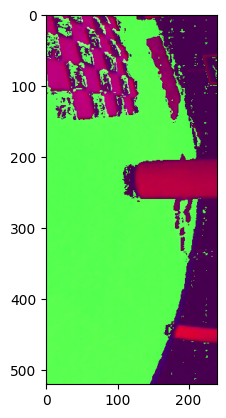

In [ ]:
# Result
import matplotlib.pyplot as plt

# Pick the first image to test
f = images[0]
lf = f.replace('c.jpg', 'm.jpg')

img = cv2.imread(f)
h,w,d = img.shape

# Color space of RAW Bebop Images
yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

# Reshape into flat list, and slice [:, 1:3] to keep ONLY U and V!
X_run = yuv.reshape(int(h*w), int(d))[:, 1:3]

# Predict
y_pred = dt.predict(X_run)

# Reshape back to image dimensions
msk = y_pred.reshape(h,w)

# Tint the green channel of the original image with the predicted mask
img[:,:,1] = msk[:,:]

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

# Next steps

 - Improve the classifier by for instance changing the ```max_depth```
 - Plot the quality of each classifier you make as a point in the ROC-curve (TP/FP)
 - What happens with the _sensitivity_ when you add more images with changes in appearance (e.g. from the simulator)
 - Augment your dataset to make the classification still work with more/less light (e.g. from the _dataset.zip_)
 - Try to find other types of obstacles or more classes of obstacles.